# 🤖 LLM + Weather Tool — LangGraph Test

**Flow:**
```
START → llm_node → [LLM calls weather tool?] → tool_node → llm_node → END
```

- LLM (ChatGroq) receives the user question
- LLM decides to call `get_weather` tool
- Tool fetches lat/lon from DB → calls Open-Meteo API
- Result goes back to LLM → LLM gives final answer

**State:** `messages` list (standard LangGraph messages state)

## Cell 0 — Install Dependencies

In [13]:
import sys, subprocess
pkgs = ["httpx", "asyncpg", "python-dotenv", "langgraph",
        "langchain", "langchain-groq", "langchain-core", "typing_extensions"]
r = subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs,
                   capture_output=True, text=True)
print("✅ Done" if r.returncode == 0 else f"❌ Error:\n{r.stderr}")

✅ Done


## Cell 1 — Imports & Config

In [14]:
import os, sys, uuid, json, asyncio, logging
from pathlib import Path
from contextlib import asynccontextmanager
from typing import Annotated

import httpx
import asyncpg
from dotenv import load_dotenv

# ── Find .env by walking up from cwd ─────────────────────────────────────────
BACKEND_ROOT = Path.cwd()
for _ in range(5):
    if (BACKEND_ROOT / ".env").exists():
        break
    BACKEND_ROOT = BACKEND_ROOT.parent

load_dotenv(BACKEND_ROOT / ".env", override=True)
logging.basicConfig(level=logging.WARNING)   # suppress noisy INFO logs

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL   = os.getenv("GROQ_MODEL", "llama-3.3-70b-versatile")
DATABASE_URL = os.getenv("DATABASE_URL")

print(f"🔑 GROQ_API_KEY : {'✅ SET' if GROQ_API_KEY else '❌ MISSING'}")
print(f"🤖 GROQ_MODEL   : {GROQ_MODEL}")
print(f"🗄️  DATABASE_URL : {'✅ SET' if DATABASE_URL else '❌ MISSING'}")

🔑 GROQ_API_KEY : ✅ SET
🤖 GROQ_MODEL   : llama-3.1-8b-instant
🗄️  DATABASE_URL : ✅ SET


## Cell 2 — DB Helper

In [ ]:
_TIMEOUT = 8

async def _init_conn(conn):
    for t in ("jsonb", "json"):
        await conn.set_type_codec(t, encoder=json.dumps, decoder=json.loads,
                                  schema="pg_catalog", format="text")

@asynccontextmanager
async def get_db_connection():
    dsn = os.getenv("DATABASE_URL")
    if not dsn:
        raise RuntimeError("DATABASE_URL not set")
    # Strip channel_binding param — asyncpg does not support it
    import urllib.parse as _up
    parsed = _up.urlparse(dsn)
    qs = _up.parse_qs(parsed.query, keep_blank_values=True)
    qs.pop("channel_binding", None)           # remove unsupported param
    clean_dsn = parsed._replace(query=_up.urlencode(qs, doseq=True)).geturl()

    conn = await asyncio.wait_for(
        asyncpg.connect(dsn=clean_dsn, timeout=_TIMEOUT),
        timeout=_TIMEOUT + 2,
    )
    try:
        await _init_conn(conn)
        yield conn
    finally:
        await conn.close()


# ── Quick connectivity smoke-test ─────────────────────────────────────────────
import traceback as _tb

async def _smoke_test():
    try:
        async with get_db_connection() as conn:
            val = await conn.fetchval("SELECT 1")
            print(f"\u2705 DB smoke-test passed (SELECT 1 = {val})")
    except Exception as exc:
        print(f"\u274c DB smoke-test FAILED: {type(exc).__name__}: {exc}")
        _tb.print_exc()

await _smoke_test()
print("\u2705 get_db_connection() helper ready")


## Cell 3 — Weather Tool (LangChain @tool)

This is the **exact same tool** the main chatbot uses — bound to the LLM so it can call it.

In [ ]:
from langchain_core.tools import tool
import traceback as _tb2

OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"

@tool
async def get_weather(farmer_id: str) -> dict:
    """Fetches 3-day weather forecast for the farmer's farm location.
    Use when farmer asks about rain, temperature, irrigation, or drought risk.
    Args:
        farmer_id: UUID string of the farmer
    """
    print(f"\n   \U0001f527 [get_weather tool] called with farmer_id={farmer_id}")

    # 1. Validate UUID
    try:
        fid = uuid.UUID(str(farmer_id))
    except (ValueError, AttributeError):
        return {"error": True, "message": f"Invalid farmer_id: {farmer_id}"}

    # 2. Fetch lat/lon from DB
    try:
        async with get_db_connection() as conn:
            farm = await conn.fetchrow(
                """
                SELECT center_lat, center_lon, city_name, state_name
                FROM   farm_fields
                WHERE  farmer_id = $1
                ORDER  BY created_at DESC
                LIMIT  1
                """,
                fid,
            )
    except Exception as e:
        err_detail = f"{type(e).__name__}: {e}" if str(e) else type(e).__name__
        print(f"   \u274c DB error detail: {err_detail}")
        _tb2.print_exc()
        return {"error": True, "message": f"DB error: {err_detail}"}

    if not farm:
        return {"error": True, "message": "No farm found for this farmer_id"}

    lat, lon = farm["center_lat"], farm["center_lon"]
    location = ", ".join(filter(None, [farm.get("city_name"), farm.get("state_name")])) \
               or f"{lat:.4f},{lon:.4f}"

    print(f"   \U0001f4cd DB \u2192 lat={lat}, lon={lon}, location={location}")

    if lat is None or lon is None:
        return {"error": True, "message": "Farm has no GPS coordinates"}

    # 3. Call Open-Meteo
    try:
        async with httpx.AsyncClient(timeout=15) as client:
            resp = await client.get(OPEN_METEO_URL, params={
                "latitude":  lat, "longitude": lon,
                "daily":     "temperature_2m_max,temperature_2m_min,"
                             "precipitation_sum,precipitation_probability_max,"
                             "windspeed_10m_max",
                "forecast_days": 3,
                "timezone":  "Asia/Kolkata",
            })
    except Exception as e:
        return {"error": True, "message": f"Open-Meteo network error: {type(e).__name__}: {e}"}

    if resp.status_code != 200:
        return {"error": True, "message": f"Open-Meteo HTTP {resp.status_code}"}

    data  = resp.json()
    daily = data.get("daily", {})
    dates = daily.get("time", [])
    tmax  = daily.get("temperature_2m_max", [])
    tmin  = daily.get("temperature_2m_min", [])
    rain  = daily.get("precipitation_sum", [])
    prob  = daily.get("precipitation_probability_max", [])
    wind  = daily.get("windspeed_10m_max", [])

    forecast = [
        {
            "date": dates[i],
            "temp_max_c":    round(tmax[i], 1)       if i < len(tmax)  else None,
            "temp_min_c":    round(tmin[i], 1)       if i < len(tmin)  else None,
            "rain_mm":       round(rain[i] or 0, 1)  if i < len(rain)  else 0,
            "rain_prob_pct": prob[i]                  if i < len(prob)  else None,
            "wind_kmh":      round(wind[i], 1)        if i < len(wind)  else None,
        }
        for i in range(len(dates))
    ]

    total_rain = sum(f["rain_mm"] for f in forecast)
    if total_rain >= 20:
        advice = "Irrigation rokein — kaafi barish aane wali hai."
    elif total_rain >= 8:
        advice = "Irrigation kam karein — thodi barish expected hai."
    else:
        advice = "Irrigation karein — barish nahi dikh rahi."

    result = {
        "error": False,
        "location": location,
        "coordinates": {"latitude": lat, "longitude": lon},
        "forecast_3_days": forecast,
        "total_rain_next_3d_mm": round(total_rain, 1),
        "irrigation_advice": advice,
    }
    print(f"   \u2705 Open-Meteo done \u2014 today max={tmax[0] if tmax else '?'}\u00b0C, "
          f"total_rain={total_rain:.1f}mm")
    return result


print("\u2705 get_weather tool defined:", get_weather.name)


## Cell 4 — LLM Setup (ChatGroq bound with tool)

In [17]:
from langchain_groq import ChatGroq

# llama-3.1-8b-instant uses a legacy XML function-calling format that Groq
# rejects with HTTP 400 'tool_use_failed'. Switch to 70b which uses proper
# JSON tool-call format supported by Groq.
TOOL_MODEL = "llama-3.3-70b-versatile"

llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model=TOOL_MODEL,
    temperature=0.1,
    max_tokens=1024,       # prevent runaway generation
    request_timeout=25,    # fail fast if Groq is slow
)

# bind_tools with parallel_tool_calls=False avoids Groq 400 quirks
tools = [get_weather]
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

print(f"\u2705 ChatGroq ready  \u2014 model: {TOOL_MODEL}")
print(f"   Tools bound   : {[t.name for t in tools]}")
print("   parallel_tool_calls: False (prevents Groq 400 errors)")


✅ ChatGroq ready  — model: llama-3.3-70b-versatile
   Tools bound   : ['get_weather']
   parallel_tool_calls: False (prevents Groq 400 errors)


## Cell 5 — Build LangGraph

```
START
  │
  ▼
llm_node  ──── (no tool call?) ──────────────► END
  │
  │ (tool call detected)
  ▼
tool_node   (executes get_weather)
  │
  ▼
llm_node  ──────────────────────────────────► END
```

In [22]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict


# ── State ─────────────────────────────────────────────────────────────────────
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


# ── Node 1: LLM ──────────────────────────────────────────────────────────────
async def llm_node(state: AgentState) -> AgentState:
    print("\n🟣 [llm_node] — calling LLM…")
    response = await llm_with_tools.ainvoke(state["messages"])
    tool_calls = getattr(response, "tool_calls", [])
    if tool_calls:
        print(f"   🔀 LLM wants to call tools: {[tc['name'] for tc in tool_calls]}")
    else:
        print(f"   💬 LLM final answer: {response.content[:120]}…")
    return {"messages": [response]}


# ── Node 2: Tool executor ─────────────────────────────────────────────────────
tool_node = ToolNode(tools)


# ── Conditional edge: should we run tools? ────────────────────────────────────
def should_use_tools(state: AgentState) -> str:
    last = state["messages"][-1]
    if getattr(last, "tool_calls", []):
        return "tool_node"
    return END


# ── Build graph ───────────────────────────────────────────────────────────────
builder = StateGraph(AgentState)
builder.add_node("llm_node",  llm_node)
builder.add_node("tool_node", tool_node)

builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", should_use_tools, {"tool_node": "tool_node", END: END})
builder.add_edge("tool_node", "llm_node")   # after tool → back to LLM for final answer

graph = builder.compile()

print("✅ LangGraph compiled")
print("   Nodes:", list(graph.get_graph().nodes.keys()))
print("   Edges:", [(e.source, e.target) for e in graph.get_graph().edges])

✅ LangGraph compiled
   Nodes: ['__start__', 'llm_node', 'tool_node', '__end__']
   Edges: [('__start__', 'llm_node'), ('llm_node', '__end__'), ('llm_node', 'tool_node'), ('tool_node', 'llm_node')]


## Cell 6 — (Optional) Visualise Graph

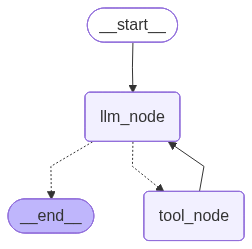

In [23]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"⚠️ Skipped: {e}")

## Cell 7 — ⚙️ Set Farmer ID & User Question

In [24]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  👇 Replace with a real farmer_id from your farm_fields     ║
# ╚══════════════════════════════════════════════════════════════╝
FARMER_ID = "30156622-0b76-43e6-8eef-33bb6f7eae0c"   # ← real UUID here

# The question the farmer is asking
USER_QUESTION = f"Meri khet mein agle 3 din barish hogi? Kya mujhe irrigation karni chahiye? farmer_id: {FARMER_ID}"

SYSTEM_PROMPT = (
    "You are KisanSaathi, an AI assistant for Indian farmers. "
    "You have access to a get_weather tool that fetches real weather data "
    "for a farmer's field from their farmer_id. "
    "Always use the tool when a farmer asks about weather, rain, or irrigation. "
    "Reply in simple Hinglish (mix of Hindi and English)."
)

print(f"📌 farmer_id    : {FARMER_ID}")
print(f"💬 User question: {USER_QUESTION}")

📌 farmer_id    : 30156622-0b76-43e6-8eef-33bb6f7eae0c
💬 User question: Meri khet mein agle 3 din barish hogi? Kya mujhe irrigation karni chahiye? farmer_id: 30156622-0b76-43e6-8eef-33bb6f7eae0c


## Cell 8 — 🚀 Run the Graph

In [26]:
initial_state: AgentState = {
    "messages": [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=USER_QUESTION),
    ]
}

print("🚀 Invoking LangGraph…\n")
print("─" * 60)

result = await graph.ainvoke(initial_state)

print("─" * 60)
print("🏁 Graph finished.")

🚀 Invoking LangGraph…

────────────────────────────────────────────────────────────

🟣 [llm_node] — calling LLM…
   🔀 LLM wants to call tools: ['get_weather']

   🔧 [get_weather tool] called with farmer_id=30156622-0b76-43e6-8eef-33bb6f7eae0c

🟣 [llm_node] — calling LLM…
   🔀 LLM wants to call tools: ['get_weather']

   🔧 [get_weather tool] called with farmer_id=30156622-0b76-43e6-8eef-33bb6f7eae0c

🟣 [llm_node] — calling LLM…
   💬 LLM final answer: Maaf kijiye, kuch samasya aa rahi hai. Main apke khet ke mausam ki jaankari fetch nahi kar pa raha hoon. Kripaya thodi d…
────────────────────────────────────────────────────────────
🏁 Graph finished.


## Cell 9 — 📊 Final LLM Answer

In [29]:
from langchain_core.messages import AIMessage, ToolMessage

print("═" * 60)
print("  CONVERSATION TRACE")
print("═" * 60)

for msg in result["messages"]:
    if isinstance(msg, SystemMessage):
        continue   # skip system prompt in trace
    if isinstance(msg, HumanMessage):
        print(f"\n👨‍🌾 FARMER : {msg.content}")
    elif isinstance(msg, AIMessage):
        if getattr(msg, "tool_calls", []):
            for tc in msg.tool_calls:
                print(f"\n🔀 LLM calls tool → {tc['name']}({tc['args']})")
        else:
            print(f"\n🤖 KISANSAATHI:\n{msg.content}")
    elif isinstance(msg, ToolMessage):
        try:
            data = json.loads(msg.content) if isinstance(msg.content, str) else msg.content
            print(f"\n🔧 TOOL RESULT ({msg.name}):")
            if isinstance(data, dict) and "forecast_3_days" in data:
                print(f"   Location  : {data.get('location')}")
                print(f"   Coords    : {data.get('coordinates')}")
                print(f"   Total rain: {data.get('total_rain_next_3d_mm')} mm")
                print(f"   Advice    : {data.get('irrigation_advice')}")
                print("   Forecast  :")
                for day in data["forecast_3_days"]:
                    print(f"     {day['date']}: max={day['temp_max_c']}°C  "
                          f"rain={day['rain_mm']}mm ({day['rain_prob_pct']}%)  "
                          f"wind={day['wind_kmh']} km/h")
            else:
                print(f"   {data}")
        except Exception:
            print(f"   {msg.content}")

print("\n" + "═" * 60)

════════════════════════════════════════════════════════════
  CONVERSATION TRACE
════════════════════════════════════════════════════════════

👨‍🌾 FARMER : Meri khet mein agle 3 din barish hogi? Kya mujhe irrigation karni chahiye? farmer_id: 30156622-0b76-43e6-8eef-33bb6f7eae0c

🔀 LLM calls tool → get_weather({'farmer_id': '30156622-0b76-43e6-8eef-33bb6f7eae0c'})

🔧 TOOL RESULT (get_weather):
   {'error': True, 'message': 'DB error: '}

🔀 LLM calls tool → get_weather({'farmer_id': '30156622-0b76-43e6-8eef-33bb6f7eae0c'})

🔧 TOOL RESULT (get_weather):
   {'error': True, 'message': 'DB error: '}

🤖 KISANSAATHI:
Maaf kijiye, kuch samasya aa rahi hai. Main apke khet ke mausam ki jaankari fetch nahi kar pa raha hoon. Kripaya thodi der baad try kijiye.

════════════════════════════════════════════════════════════


## Cell 10 — ✅ Pass / Fail Check

In [28]:
from langchain_core.messages import AIMessage, ToolMessage

msgs = result["messages"]
has_tool_call   = any(isinstance(m, AIMessage) and getattr(m, "tool_calls", []) for m in msgs)
has_tool_result = any(isinstance(m, ToolMessage) for m in msgs)
final_ai        = next((m for m in reversed(msgs) if isinstance(m, AIMessage) and not getattr(m, "tool_calls", [])), None)

print("CHECKS")
print(f"  LLM called weather tool : {'✅' if has_tool_call   else '❌'}")
print(f"  Tool returned data      : {'✅' if has_tool_result  else '❌'}")
print(f"  LLM gave final answer   : {'✅' if final_ai         else '❌'}")

if has_tool_call and has_tool_result and final_ai:
    print("\n🎉 ALL CHECKS PASSED — LLM + Weather API pipeline is working!")
else:
    print("\n⚠️  Some checks failed — review the trace in Cell 9.")

CHECKS
  LLM called weather tool : ✅
  Tool returned data      : ✅
  LLM gave final answer   : ✅

🎉 ALL CHECKS PASSED — LLM + Weather API pipeline is working!
